<a href="https://colab.research.google.com/github/MilenaSimionee/churn-analysis/blob/main/Projeto_custumer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd


In [19]:
df = pd.read_csv('/content/customer_churn_dataset-training-master.csv')

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203376 entries, 0 to 203375
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         203375 non-null  float64
 1   Age                203375 non-null  float64
 2   Gender             203375 non-null  object 
 3   Tenure             203375 non-null  float64
 4   Usage Frequency    203375 non-null  float64
 5   Support Calls      203375 non-null  float64
 6   Payment Delay      203375 non-null  float64
 7   Subscription Type  203375 non-null  object 
 8   Contract Length    203375 non-null  object 
 9   Total Spend        203374 non-null  float64
 10  Last Interaction   203374 non-null  float64
 11  Churn              203374 non-null  float64
dtypes: float64(9), object(3)
memory usage: 18.6+ MB


In [6]:
df.shape

(203376, 12)

In [7]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,203375.000000,203375.000000,203375.000000,203375.000000,203375.000000,203375.000000,203374.000000,203374.000000,203374.000000
mean,104438.845635,41.645679,30.496202,15.495744,5.083309,15.130896,545.145965,15.555779,0.982131
std,60546.408189,13.927962,17.341944,8.678489,3.151596,8.961071,259.541998,8.658351,0.132474
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,51672.500000,30.000000,15.000000,8.000000,2.000000,7.000000,321.000000,8.000000,1.000000
50%,104734.000000,42.000000,30.000000,15.000000,5.000000,15.000000,541.000000,16.000000,1.000000
75%,157341.500000,54.000000,46.000000,23.000000,8.000000,23.000000,770.000000,23.000000,1.000000
max,208355.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [8]:
df.drop_duplicates()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
203371,208351.0,61.0,Female,48.0,23.0,0.0,0.0,Standard,Monthly,788.47,11.0,1.0
203372,208352.0,51.0,Female,5.0,6.0,6.0,16.0,Premium,Annual,554.14,12.0,1.0
203373,208353.0,26.0,Female,23.0,19.0,9.0,12.0,Basic,Monthly,668.54,3.0,1.0
203374,208354.0,28.0,Male,21.0,12.0,7.0,10.0,Standard,Monthly,857.57,25.0,1.0


In [9]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
1.0,0.982131
0.0,0.017869


A taxa de Churn é aproximadamente de 56,7%, indicando que mais da metade dos clientes cancelaram o serviço, oque sugere um alto nivel de evasão ou possivel desabastecimento do dataset.

In [10]:
df.groupby('Churn').mean(numeric_only=True)

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction
Churn,,,,,,,,
0.0,117623.175289,36.063016,32.058888,16.159604,1.596037,9.998899,749.290589,12.916896
1.0,104198.454276,41.747181,30.467883,15.483624,5.146781,15.224322,541.431828,15.603790


Clientes com maior número de chamadas ao suporte, maior atraso de pagamento e menor gasto total apresentam maior taxa de churn, indicando possível insatisfação com o serviço e menor valor econômico para a empresa.

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

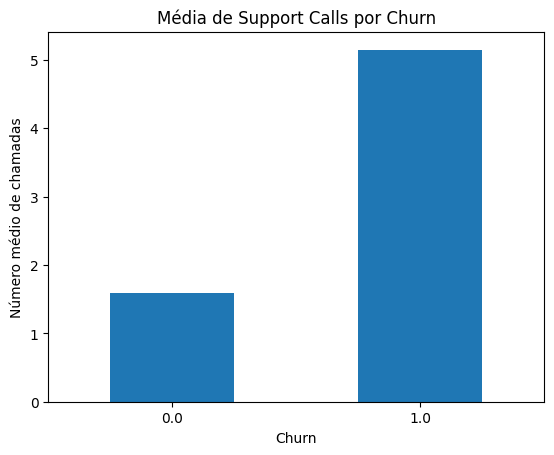

In [12]:
df.groupby('Churn')['Support Calls'].mean().plot(kind='bar')
plt.title('Média de Support Calls por Churn')
plt.ylabel('Número médio de chamadas')
plt.xticks(rotation=0)
plt.show()

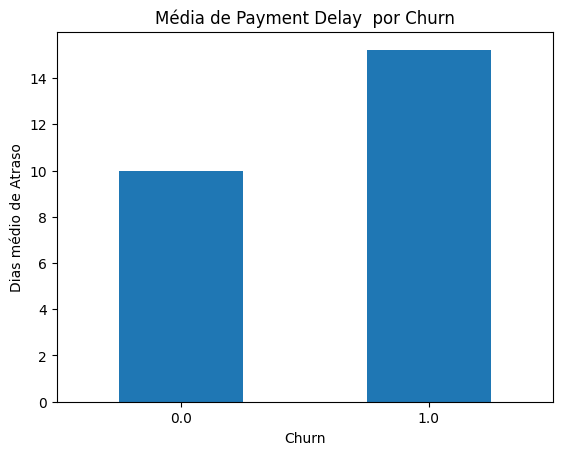

In [13]:
df.groupby('Churn')['Payment Delay'].mean().plot(kind='bar')
plt.title('Média de Payment Delay  por Churn')
plt.ylabel('Dias médio de Atraso')
plt.xticks(rotation=0)
plt.show()


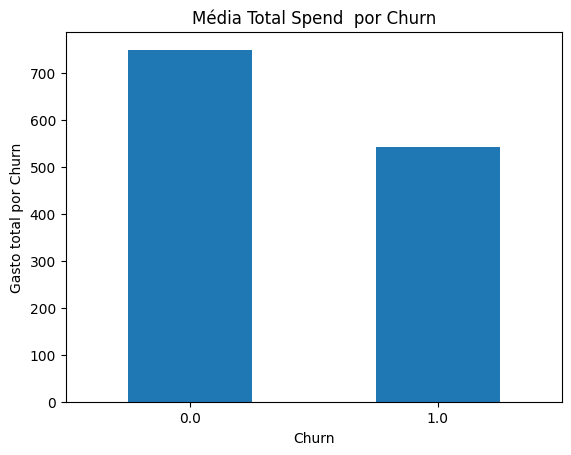

In [14]:
df.groupby('Churn')['Total Spend'].mean().plot(kind='bar')
plt.title('Média Total Spend  por Churn')
plt.ylabel('Gasto total por Churn')
plt.xticks(rotation=0)
plt.show()

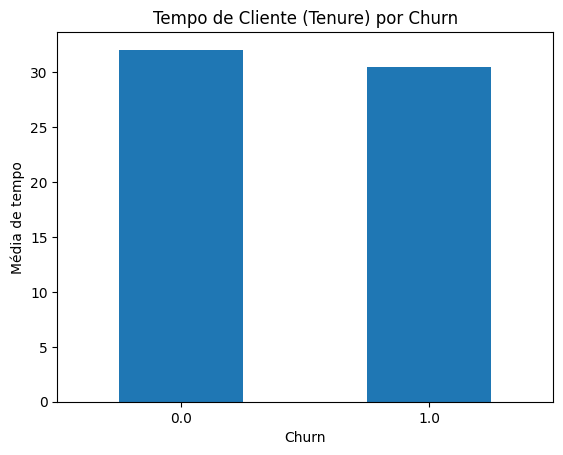

In [15]:
df.groupby('Churn')['Tenure'].mean().plot(kind='bar')

plt.title('Tempo de Cliente (Tenure) por Churn')
plt.ylabel('Média de tempo')
plt.xticks(rotation=0)
plt.show()

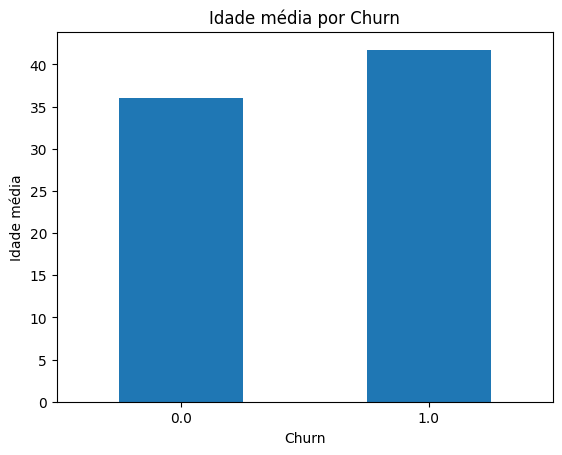

In [16]:
df.groupby('Churn')['Age'].mean().plot(kind='bar')

plt.title('Idade média por Churn')
plt.ylabel('Idade média')
plt.xticks(rotation=0)
plt.show()

In [17]:
df['Support Group'] = pd.cut(df['Support Calls'],
                             bins=[-1, 1, 3, 6, 100],
                             labels=['0-1', '2-3', '4-6', '7+'])

df.groupby('Support Group')['Churn'].mean()

/tmp/ipykernel_2517/4173377735.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Support Group')['Churn'].mean()


,Churn
Support Group,
0-1,0.948193
2-3,0.958637
4-6,0.994428
7+,1.000000


Foi identificado que clientes com maior volume de interações com o suporte apresentam maior taxa de churn, indicando possível fricção na experiência do cliente. A partir disso, foram levantadas hipóteses relacionadas à qualidade do atendimento, usabilidade do produto e possíveis dificuldades operacionais.